In [1]:
# import model and libraries the goal is to reduce the number of libraires listed here
import numpy as np
import torch
import torch.nn as nn
import sys
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from _utils import cells_to_bboxes, plot_image, non_max_suppression
import cv2
model = torch.hub.load('ultralytics/yolov5', 'yolov5n')

graph_ic = np.load("model/graph.npy", allow_pickle=True)
config_ic = np.load("model/config.npy", allow_pickle=True)
weights_ic = np.load("model/weights.npy", allow_pickle=True)
classes_ic = np.load("model/classes.npy", allow_pickle=True)

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


Using cache found in /home/geeth/.cache/torch/hub/ultralytics_yolov5_master
/home/geeth/miniconda3/envs/yolov13/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
YOLOv5 🚀 2026-3-16 Python-3.11.14 torch-2.10.0+cu128 CPU

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients, 4.5 GFLOPs
Adding AutoShape... 


In [2]:
# Computations python version
def preprocess_py(image_path, new_size=640):
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]
    r = min(new_size / h, new_size / w)
    new_unpad = (int(w * r), int(h * r))
    img_resized = cv2.resize(img, new_unpad)
    canvas = np.full((new_size, new_size, 3), 114, dtype=np.uint8)
    dw = (new_size - new_unpad[0]) // 2
    dh = (new_size - new_unpad[1]) // 2
    canvas[dh:dh+new_unpad[1], dw:dw+new_unpad[0]] = img_resized
    tensor = canvas.transpose((2, 0, 1)).astype(np.float32) / 255.0
    return tensor.tolist(), 3 * new_size * new_size

def execute_layer_py(x_list, layer_ic):
    if len(x_list) == 1:   # if more than 1 input, make x a <list> else x a <tensor>
        x = x_list[0]
    else:
        x = x_list
    operation = config_ic[layer_ic][0]

    if operation == "conv":
        _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
        w = weights_ic[layer_ic][0]
        b = weights_ic[layer_ic][1] if bias else None
        return F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))
    elif operation == "activation":
        _, inplace = config_ic[layer_ic]
        return F.silu(x, inplace=inplace)
    elif operation == "pool":
        _, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode = config_ic[layer_ic]
        return F.max_pool2d(
            x,
            kernel_size=(k_h, k_w),
            stride=(s_h, s_w),
            padding=(p_h, p_w),
            dilation=(d_h, d_w),
            ceil_mode=ceil_mode
        )
    elif operation == "upsample":
        _, scale_h, scale_w, mode = config_ic[layer_ic]
        return F.interpolate(x, scale_factor=(scale_h, scale_w), mode=mode)
    elif operation == "concat":
        return torch.cat(x, dim=1)
    elif operation == "resadd":
        return x[0] + x[1]
    elif "detect" in operation:
        large  = "detect.l" == operation        # P3/8
        medium = "detect.m" == operation        # P4/16
        small  = "detect.s" == operation        # P5/32
        final  =  "detect.f" == operation       # P3/8 + P4/16 + P5/32

        idx = 0 if large else 1 if medium else 2 if small else -1

        ####### static configs ######    
        nc = len(classes_ic)
        anchors = [
            [(10, 13), (16, 30), (33, 23)],  # P3/8
            [(30, 61), (62, 45), (59, 119)],  # P4/16
            [(116, 90), (156, 198), (373, 326)]  # P5/32#
        ]
        nl = len(anchors)
        no = 5+nc
        na = len(anchors[0])
        stride = [8, 16, 32]
        anchors_ = torch.tensor(anchors).float().view(nl, -1, 2) / torch.tensor(stride).repeat(6, 1).T.reshape(3, 3, 2)
        
        if not final:
            ####### dynamic configs ######
            _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
            ####### dynamic weights ######
            w = weights_ic[layer_ic][0]
            b = weights_ic[layer_ic][1] if bias else None

            ####### pass #######
            # 1. perform convolution
            x = F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))

            # 2. get shape
            bs, _, ny, nx = x.shape

            # 3. reshape and permute (bs, n_scale_predictions, n_grid_y, n_grid_x, 5 + num_classes)
            return x.view(bs, na, no, ny, nx).permute(0, 1, 3, 4, 2).contiguous()
        else:
            bboxes = cells_to_bboxes(x, anchors_, stride, is_pred=True, to_list=False)
            bboxes = non_max_suppression(bboxes, iou_threshold=0.45, threshold=0.25, tolist=False)
            return bboxes
    else:
        raise ValueError(f"Unsupported operation: {operation}")

# Walk the graph

# Memory structure assumptions: for any node_id memory[node_id+1] is the output of the node; prpty, only one output exist
def walker_py(memory):
    num_nodes = len(graph_ic)
    for node_id in range(num_nodes):
        input_ids = graph_ic[node_id]                               # input node_ids
        inputs = []
        for idx in input_ids:
            inputs.append(memory[idx+1])                            # get input from memory
        try:
            y = execute_layer_py(inputs, layer_ic=node_id)
            memory[node_id+1] = y # store output in memory  
        except Exception as e:
            import traceback
            traceback.print_exc()
            break
    return memory

In [3]:
# From C lib
import ctypes
lib = ctypes.CDLL("lib/libllinf.so")



# Image handling & preprocessing
lib.load_image.argtypes = [ctypes.c_char_p]
lib.load_image.restype = ctypes.c_void_p  # returns pointer to Image struct

lib.free_image.argtypes = [ctypes.c_void_p]
lib.free_image.restype = None

lib.resize_and_normalize_image.argtypes = [ctypes.c_void_p, ctypes.c_int, ctypes.c_int]
lib.resize_and_normalize_image.restype = ctypes.POINTER(ctypes.c_float)

# python wrappers
def load_image_c(path: str):
    img_ptr = lib.load_image(path.encode("utf-8"))
    if not img_ptr:
        raise RuntimeError(f"Failed to load image: {path}")
    return img_ptr

def preprocess_c(img_ptr, target_size: int = 640) -> torch.Tensor:
    out_ptr = lib.resize_and_normalize_image(img_ptr, target_size, target_size)
    tensor = np.ctypeslib.as_array(out_ptr, shape=(3, target_size, target_size))
    tensor = torch.from_numpy(tensor).unsqueeze(0)
    return tensor

def free_image_c(img_ptr):
    lib.free_image(img_ptr)

In [4]:
# Computations c version (building)

def execute_layer_c(x_list, layer_ic):
    if len(x_list) == 1:   # if more than 1 input, make x a <list> else x a <tensor>
        x = x_list[0]
    else:
        x = x_list
    operation = config_ic[layer_ic][0]

    if operation == "conv":
        _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
        w = weights_ic[layer_ic][0]
        b = weights_ic[layer_ic][1] if bias else None
        return F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))
    elif operation == "activation":
        _, inplace = config_ic[layer_ic]
        return F.silu(x, inplace=inplace)
    elif operation == "pool":
        _, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode = config_ic[layer_ic]
        return F.max_pool2d(
            x,
            kernel_size=(k_h, k_w),
            stride=(s_h, s_w),
            padding=(p_h, p_w),
            dilation=(d_h, d_w),
            ceil_mode=ceil_mode
        )
    elif operation == "upsample":
        _, scale_h, scale_w, mode = config_ic[layer_ic]
        return F.interpolate(x, scale_factor=(scale_h, scale_w), mode=mode)
    elif operation == "concat":
        return torch.cat(x, dim=1)
    elif operation == "resadd":
        return x[0] + x[1]
    elif "detect" in operation:
        large  = "detect.l" == operation        # P3/8
        medium = "detect.m" == operation        # P4/16
        small  = "detect.s" == operation        # P5/32
        final  =  "detect.f" == operation       # P3/8 + P4/16 + P5/32

        idx = 0 if large else 1 if medium else 2 if small else -1

        ####### static configs ######    
        nc = len(classes_ic)
        anchors = [
            [(10, 13), (16, 30), (33, 23)],  # P3/8
            [(30, 61), (62, 45), (59, 119)],  # P4/16
            [(116, 90), (156, 198), (373, 326)]  # P5/32#
        ]
        nl = len(anchors)
        no = 5+nc
        na = len(anchors[0])
        stride = [8, 16, 32]
        anchors_ = torch.tensor(anchors).float().view(nl, -1, 2) / torch.tensor(stride).repeat(6, 1).T.reshape(3, 3, 2)
        
        if not final:
            ####### dynamic configs ######
            _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
            ####### dynamic weights ######
            w = weights_ic[layer_ic][0]
            b = weights_ic[layer_ic][1] if bias else None

            ####### pass #######
            # 1. perform convolution
            x = F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))

            # 2. get shape
            bs, _, ny, nx = x.shape

            # 3. reshape and permute (bs, n_scale_predictions, n_grid_y, n_grid_x, 5 + num_classes)
            return x.view(bs, na, no, ny, nx).permute(0, 1, 3, 4, 2).contiguous()
        else:
            bboxes = cells_to_bboxes(x, anchors_, stride, is_pred=True, to_list=False)
            bboxes = non_max_suppression(bboxes, iou_threshold=0.45, threshold=0.25, tolist=False)
            return bboxes
    else:
        raise ValueError(f"Unsupported operation: {operation}")

# Walk the graph

# Memory structure assumptions: for any node_id memory[node_id+1] is the output of the node; prpty, only one output exist
def walker_c(memory):
    num_nodes = len(graph_ic)
    for node_id in range(num_nodes):
        input_ids = graph_ic[node_id]                               # input node_ids
        inputs = []
        for idx in input_ids:
            inputs.append(memory[idx+1])                            # get input from memory
        try:
            y = execute_layer_py(inputs, layer_ic=node_id)
            memory[node_id+1] = y # store output in memory  
        except Exception as e:
            import traceback
            traceback.print_exc()
            break
    return memory

Execution time: 0.09260869026184082 seconds


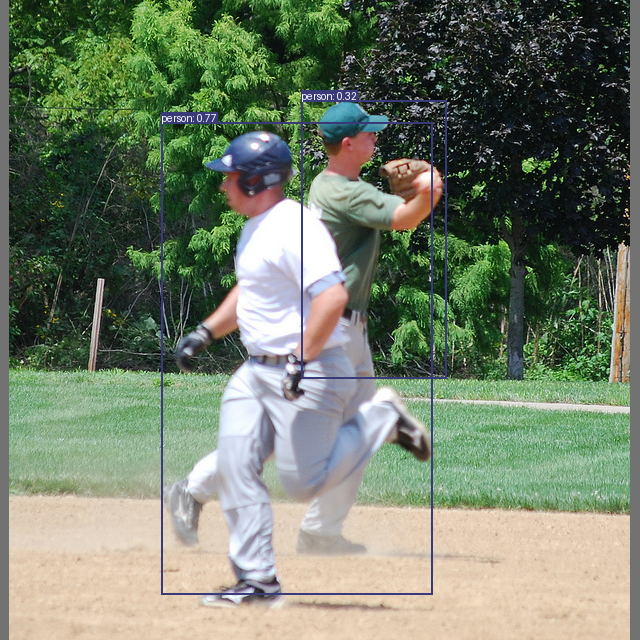

In [5]:
# Python execution
import time
im = "/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000872.jpg"
start = time.time()
img, _ = preprocess_py(im)




img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

memory = [None for _ in range(1000)] # pre allocation
memory[0] = img                      # store input image in memory at index 0
memory = walker_py(memory)

end = time.time()
print(f"Execution time: {end - start} seconds")

plot_image(
    img[0].permute(1, 2, 0).cpu(),
    memory[143],
    classes_ic
)


Execution time: 0.018480539321899414 seconds


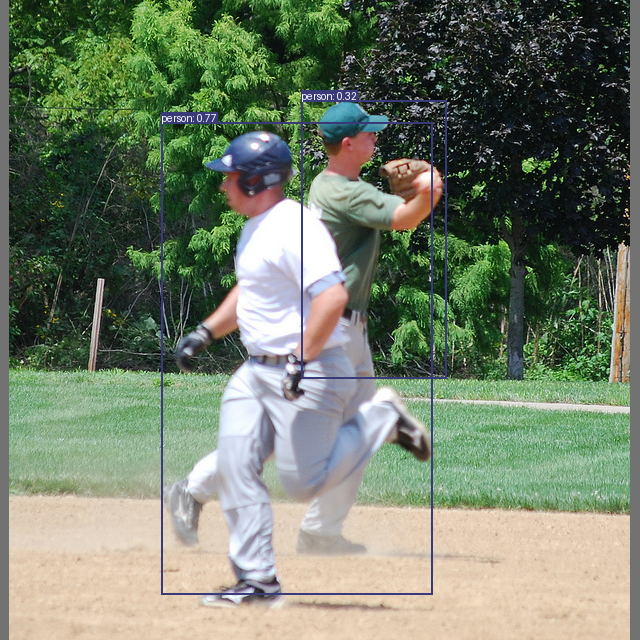

In [6]:
# C execution - our custom implementation
import time
img_ptr = load_image_c("/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000872.jpg")

start = time.time()
img_tensor = preprocess_c(img_ptr, 640)

# free_image_c(img_ptr)
# print(img_tensor.shape)

memory = [None for _ in range(1000)] # pre allocation
memory[0] = img_tensor                     # store input image in memory at index 0
memory = walker_c(memory)

end = time.time()
print(f"Execution time: {end - start} seconds")

plot_image(
    img_tensor[0].permute(1, 2, 0).cpu(),
    memory[143],
    classes_ic
)

/home/geeth/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 640x621 2 persons
Speed: 4.0ms pre-process, 21.2ms inference, 0.8ms NMS per image at shape (1, 3, 640, 640)


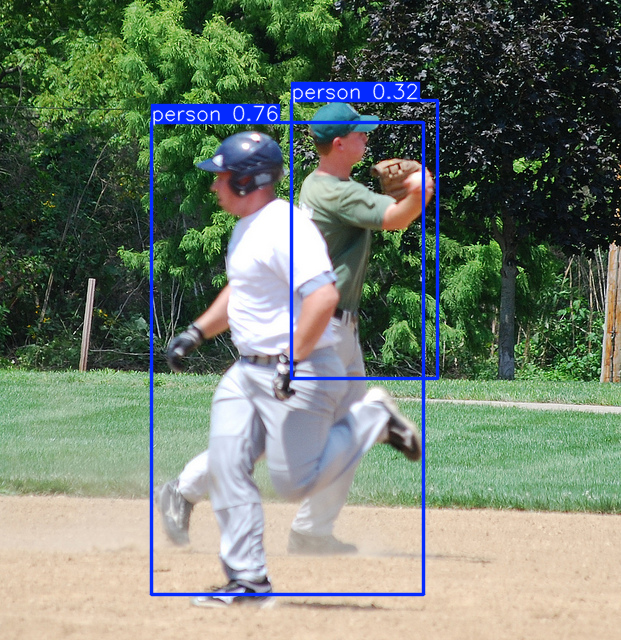

In [7]:
# official yolo inference
model.eval()
results = model(im)
results.print()
results.show()